In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    AdaptPriorResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

import torch
import matplotlib.pyplot as plt
import seaborn as sns


torch.manual_seed(42)

[2024-08-27 15:14:37,810][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-08-27 15:14:37,819][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
dl1_id = "f7b32dd97feda9f34e2b47e24fa3d18b"
dl2_id = "94efb58694007205fac996d7963f88c5"

In [3]:
metric = "val_ll_mean"
limit = 1
download_path = "/tmp"

si_restriction1 = f"dl_id = '{dl1_id}'"
si1 = (SIResult & si_restriction1).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1 = f"dl_id = '{dl1_id}'"
sbv_restriction1_50k = sbv_restriction1 + " and n_samples = 50000"
sbv1_50k = (SBVGPResult2 & sbv_restriction1_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_30k = sbv_restriction1 + " and n_samples = 30000"
sbv1_30k = (SBVGPResult2 & sbv_restriction1_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_20k = sbv_restriction1 + " and n_samples = 20000"
sbv1_20k = (SBVGPResult2 & sbv_restriction1_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_10k = sbv_restriction1 + " and n_samples = 10000"
sbv1_10k = (SBVGPResult2 & sbv_restriction1_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si1_model = torch.load(si1["model"], map_location="cpu")
sbv1_50k_model = torch.load(sbv1_50k["model"], map_location="cpu")
sbv1_30k_model = torch.load(sbv1_30k["model"], map_location="cpu")
sbv1_20k_model = torch.load(sbv1_20k["model"], map_location="cpu")
sbv1_10k_model = torch.load(sbv1_10k["model"], map_location="cpu")

In [4]:
si_restriction2 = f"dl_id = '{dl2_id}'"

si2 = (SIResult & si_restriction2).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2 = f"alt_dl_id = '{dl2_id}'"
sbv_restriction2_50k = sbv_restriction2 + " and n_samples = 50000"
sbv2_50k = (SBVGPAdaptedResult & sbv_restriction2_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_30k = sbv_restriction2 + " and n_samples = 30000"
sbv2_30k = (SBVGPAdaptedResult & sbv_restriction2_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_20k = sbv_restriction2 + " and n_samples = 20000"
sbv2_20k = (SBVGPAdaptedResult & sbv_restriction2_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_10k = sbv_restriction2 + " and n_samples = 10000"
sbv2_10k = (SBVGPAdaptedResult & sbv_restriction2_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si2_model = torch.load(si2["model"], map_location="cpu")
sbv2_50k_model = torch.load(sbv2_50k["model"], map_location="cpu")
sbv2_30k_model = torch.load(sbv2_30k["model"], map_location="cpu")
sbv2_20k_model = torch.load(sbv2_20k["model"], map_location="cpu")
sbv2_10k_model = torch.load(sbv2_10k["model"], map_location="cpu")

In [5]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

In [6]:
data_dim = 0
cond_dim = 1
reduction = "mean"
uncertainty = "none"
normalize = "none"
unit = "bits"

evaluate_pred_model = lambda model, data_loader: compute_logl(
    model,
    data_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [7]:
train_si1_data1 = evaluate_pred_model(si1_model, train_loader1)[0]
val_si1_data1 = evaluate_pred_model(si1_model, val_loader1)[0]
test_si1_data1 = evaluate_pred_model(si1_model, test_loader1)[0]

train_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, train_loader1)[0]
val_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, val_loader1)[0]
test_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, test_loader1)[0]

train_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, train_loader1)[0]
val_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, val_loader1)[0]
test_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, test_loader1)[0]

train_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, train_loader1)[0]
val_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, val_loader1)[0]
test_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, test_loader1)[0]

train_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, train_loader1)[0]
val_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, val_loader1)[0]
test_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, test_loader1)[0]

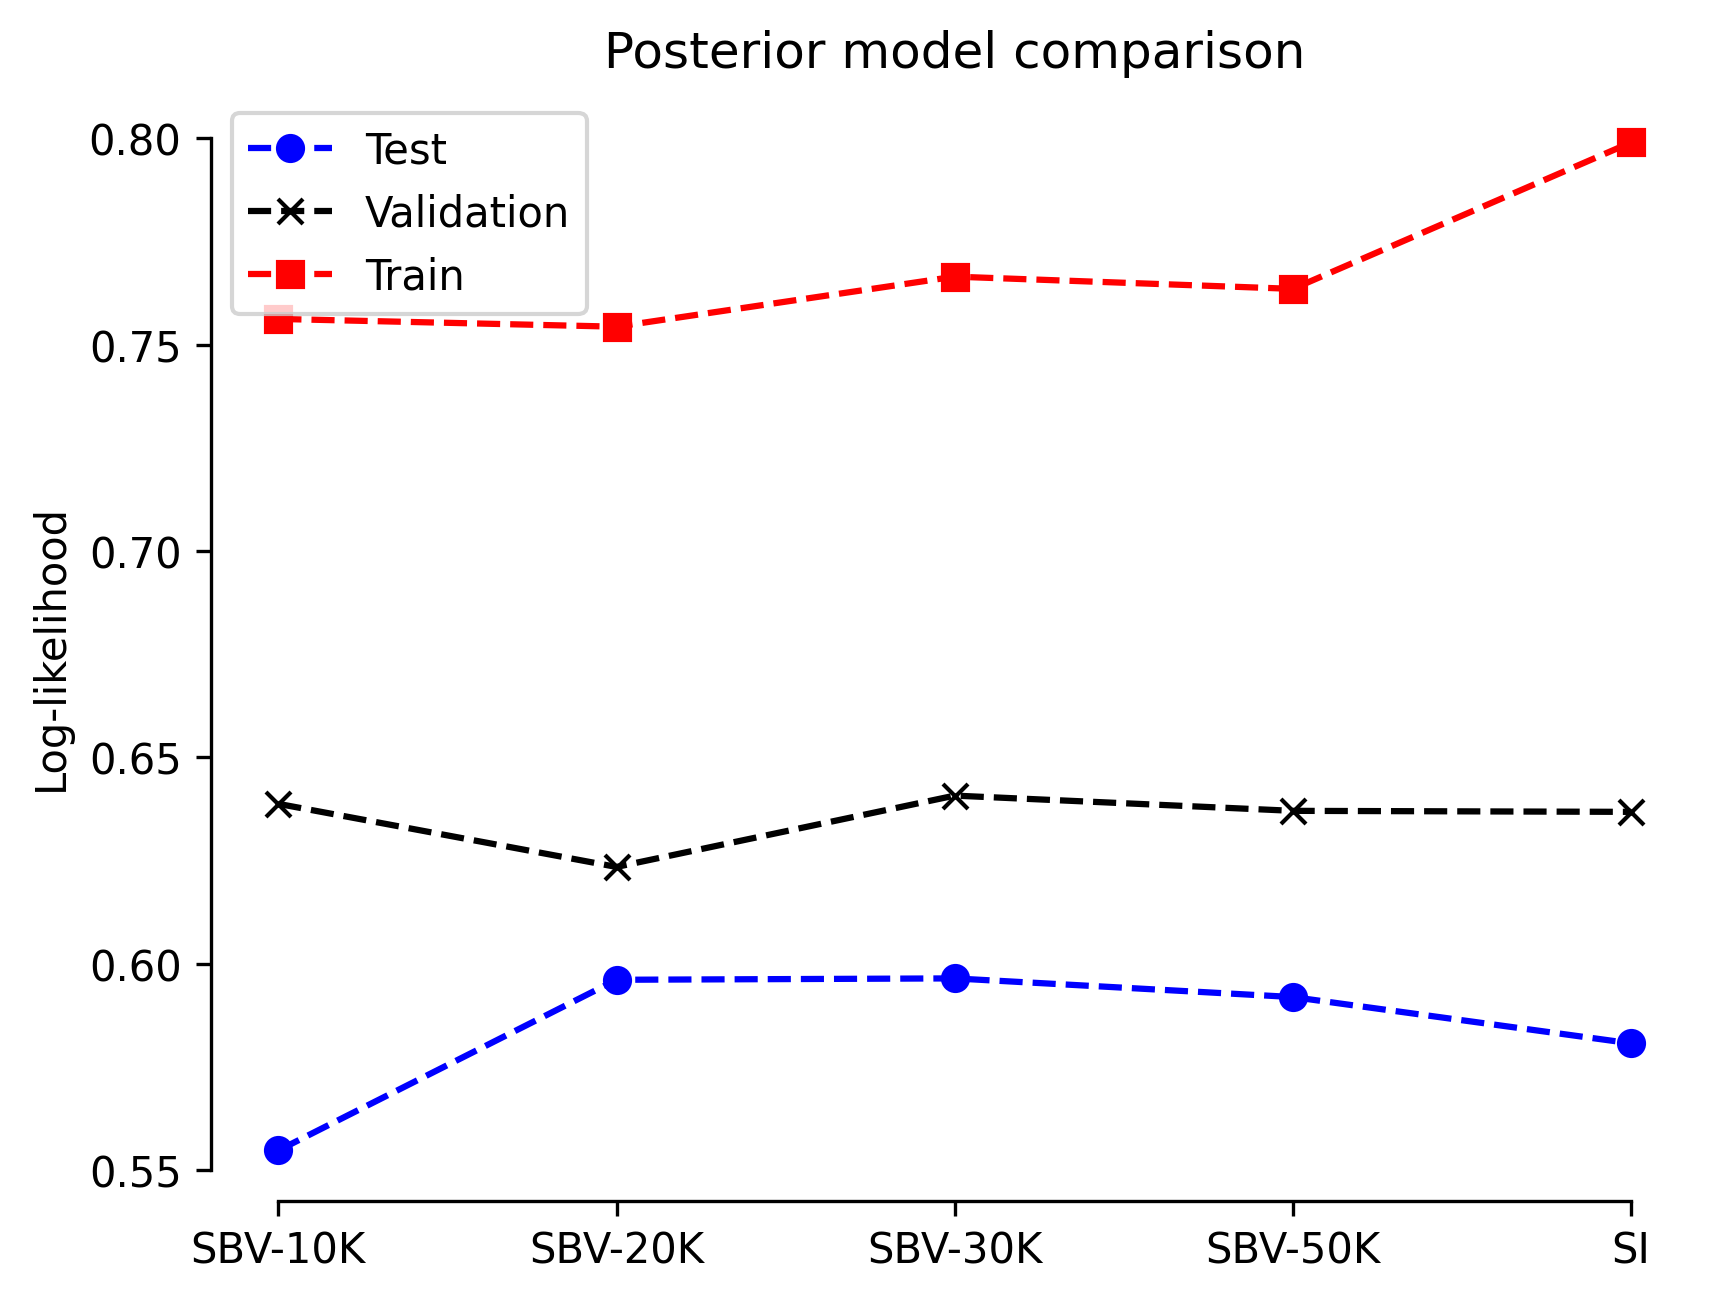

In [8]:
train_metrics_data1 = [
    train_si1_data1,
    train_sbv1_50k_data1,
    train_sbv1_30k_data1,
    train_sbv1_20k_data1,
    train_sbv1_10k_data1,
]
val_metrics_data1 = [
    val_si1_data1,
    val_sbv1_50k_data1,
    val_sbv1_30k_data1,
    val_sbv1_20k_data1,
    val_sbv1_10k_data1,
]
test_metrics_data1 = [
    test_si1_data1,
    test_sbv1_50k_data1,
    test_sbv1_30k_data1,
    test_sbv1_20k_data1,
    test_sbv1_10k_data1,
]

# Update the x-axis labels
x = ["SI", "SBV-50K", "SBV-30K", "SBV-20K", "SBV-10K"]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1], test_metrics_data1[::-1], color="blue", marker="o", linestyle="--", label="Test"
)
ax.plot(
    x[::-1],
    val_metrics_data1[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1], train_metrics_data1[::-1], color="red", marker="s", linestyle="--", label="Train"
)

sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Posterior model comparison")
ax.legend()
plt.show()

In [9]:
train_si2_data2 = evaluate_pred_model(si2_model, train_loader2)[0]
val_si2_data2 = evaluate_pred_model(si2_model, val_loader2)[0]
test_si2_data2 = evaluate_pred_model(si2_model, test_loader2)[0]

train_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, train_loader2)[0]
val_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, val_loader2)[0]
test_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, test_loader2)[0]

train_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, train_loader2)[0]
val_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, val_loader2)[0]
test_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, test_loader2)[0]

train_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, train_loader2)[0]
val_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, val_loader2)[0]
test_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, test_loader2)[0]

train_si1_data2 = evaluate_pred_model(si1_model, train_loader2)[0]
val_si1_data2 = evaluate_pred_model(si1_model, val_loader2)[0]
test_si1_data2 = evaluate_pred_model(si1_model, test_loader2)[0]

train_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, train_loader2)[0]
val_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, val_loader2)[0]
test_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, test_loader2)[0]

train_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, train_loader2)[0]
val_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, val_loader2)[0]
test_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, test_loader2)[0]

train_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, train_loader2)[0]
val_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, val_loader2)[0]
test_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, test_loader2)[0]

train_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, train_loader2)[0]
val_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, val_loader2)[0]
test_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, test_loader2)[0]


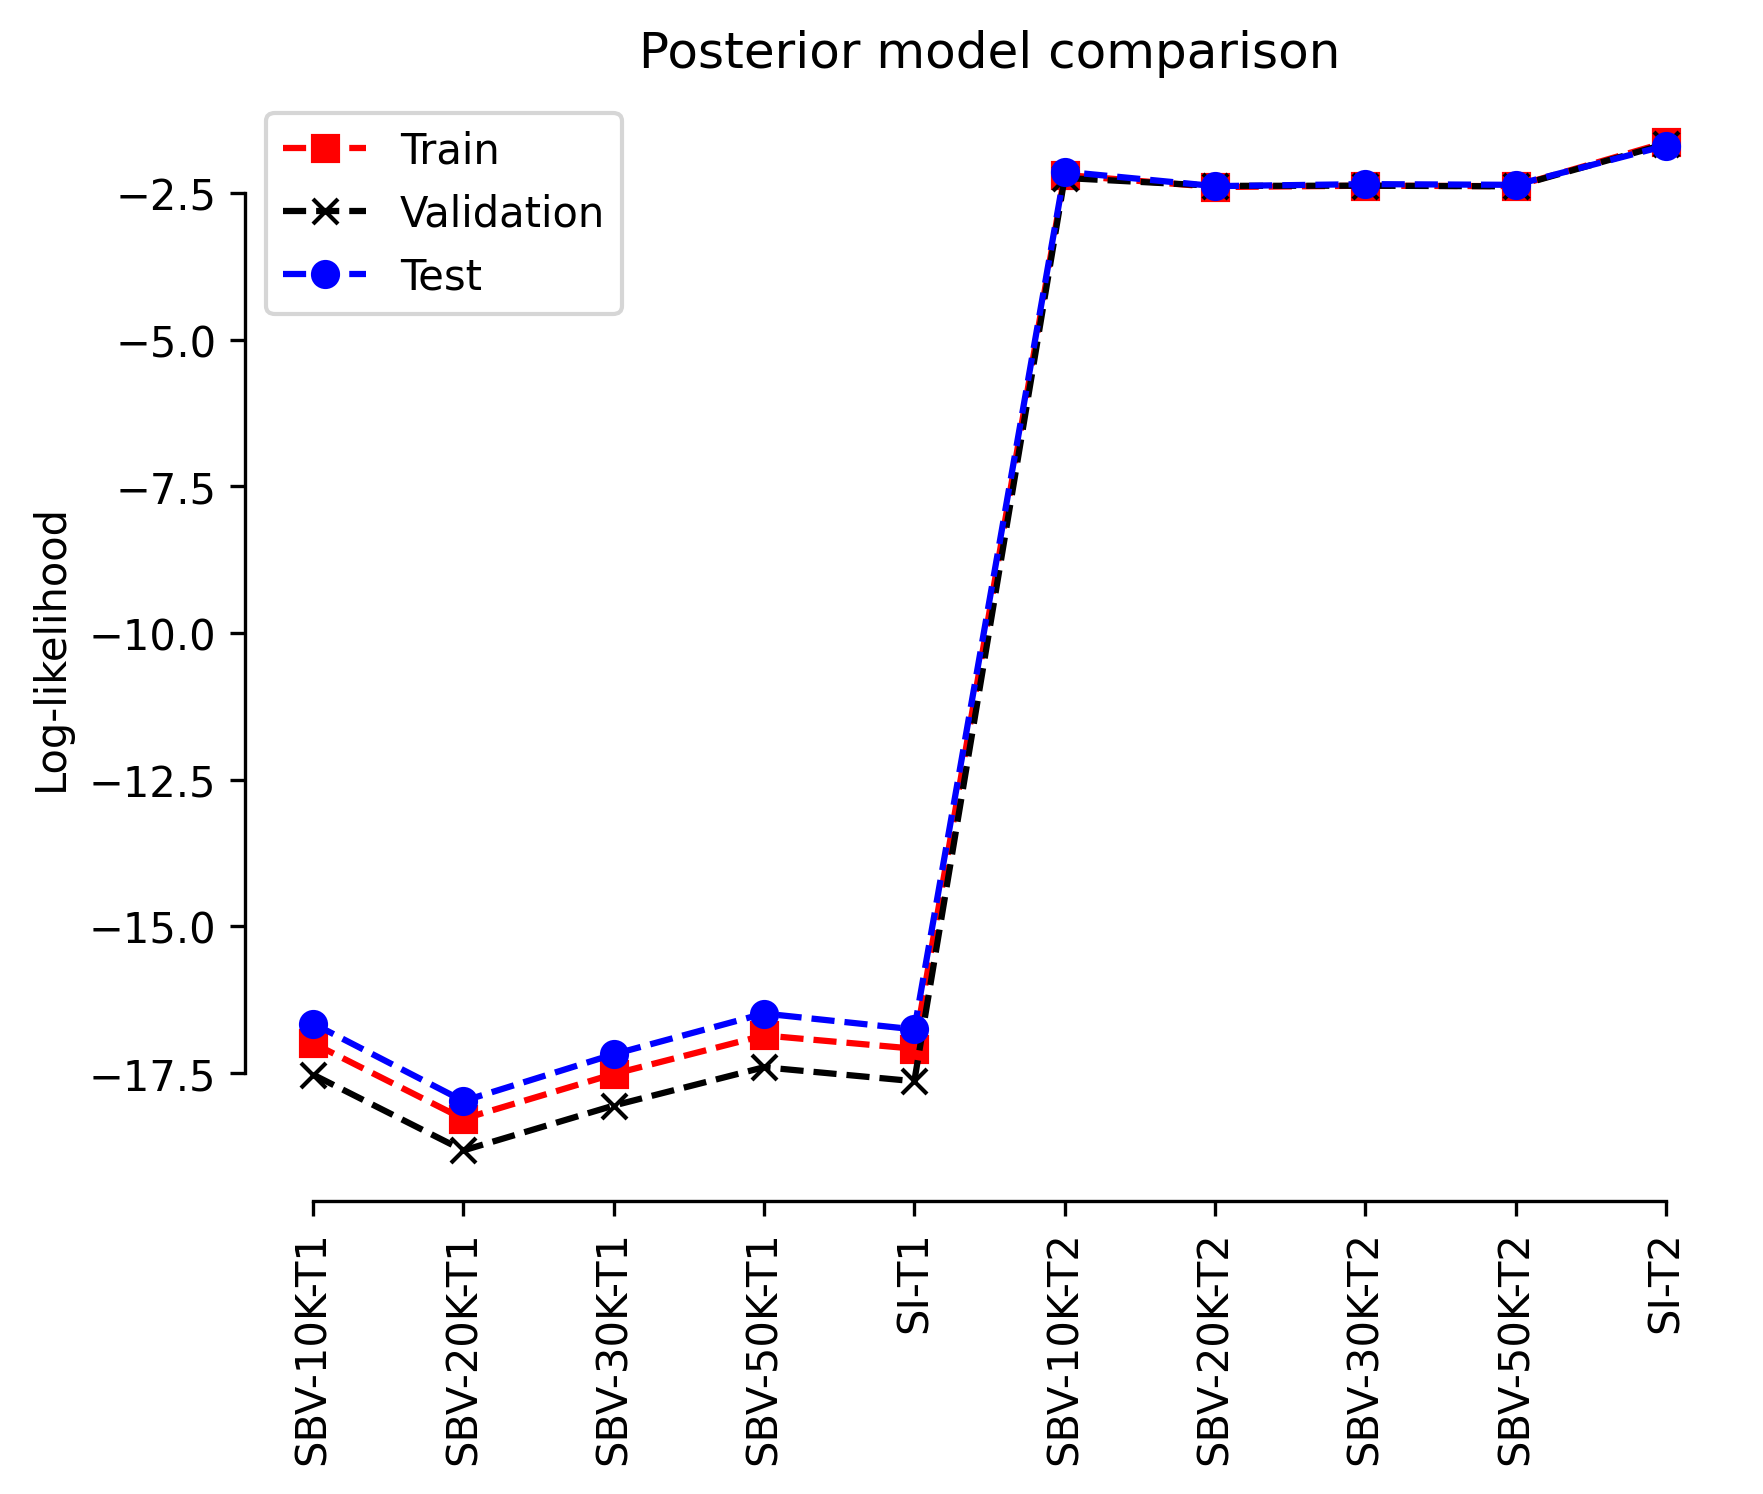

In [10]:
train_metrics_data2 = [
    train_si2_data2,
    train_sbv2_50k_data2,
    train_sbv2_30k_data2,
    train_sbv2_20k_data2,
    train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    train_sbv1_30k_data2,
    train_sbv1_20k_data2,
    train_sbv1_10k_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    val_sbv2_50k_data2,
    val_sbv2_30k_data2,
    val_sbv2_20k_data2,
    val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    val_sbv1_30k_data2,
    val_sbv1_20k_data2,
    val_sbv1_10k_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    test_sbv2_50k_data2,
    test_sbv2_30k_data2,
    test_sbv2_20k_data2,
    test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    test_sbv1_30k_data2,
    test_sbv1_20k_data2,
    test_sbv1_10k_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    "SBV-50K-T2",
    "SBV-30K-T2",
    "SBV-20K-T2",
    "SBV-10K-T2",
    "SI-T1",
    "SBV-50K-T1",
    "SBV-30K-T1",
    "SBV-20K-T1",
    "SBV-10K-T1",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1], train_metrics_data2[::-1], color="red", marker="s", linestyle="--", label="Train",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1], test_metrics_data2[::-1], color="blue", marker="o", linestyle="--", label="Test",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
plt.xticks(rotation=90)
ax.set_ylabel("Log-likelihood")
ax.set_title("Posterior model comparison")
ax.legend()
plt.show()